# 02 — Wait Time Distribution

**Business question:** What does a typical wait look like, what does the tail look like, and is the
mean a reliable number to set a service target against?


## Methodology

All statistics exclude visits flagged `wait_implausible_flag` (waits over `max_plausible_wait_minutes`),
per `docs/measure_spec.md`. Shape is characterized with skewness (asymmetry) and excess kurtosis
(tail weight relative to a normal distribution: 0 = normal, negative = flatter/thinner-tailed than
normal, positive = more sharply peaked with heavier tails).


In [1]:
import sys
from pathlib import Path

# Make the shared erops package importable when the kernel's cwd is notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import plotly.express as px
import plotly.io as pio

# Static PNG output so every chart renders identically in Jupyter, VS Code,
# nbviewer and GitHub's notebook preview -- no JS runtime required to view it.
pio.renderers.default = "png"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

from erops import metrics

con = metrics.get_connection()
print(f"Connected to {metrics.WAREHOUSE}")


Connected to C:\Users\dhwan\OneDrive\Desktop\PROJECTS\er-throughput-analytics\data\er.duckdb


### Summary statistics


In [2]:
stats = metrics.wait_summary_stats(con)
pd.Series(stats)


n_plausible      9216.000000
n_implausible       0.000000
min_wait           10.000000
median_wait        35.000000
mean_wait          35.259874
p90_wait           56.000000
p99_wait           60.000000
max_wait           60.000000
sd_wait            14.735323
skew_wait          -0.020405
kurt_wait          -1.200873
dtype: float64

In [3]:
print(f"n = {stats['n_plausible']:,.0f} plausible visits ({stats['n_implausible']:.0f} excluded as implausible)")
print(f"Median: {stats['median_wait']:.1f} min   Mean: {stats['mean_wait']:.1f} min   SD: {stats['sd_wait']:.1f} min")
print(f"P90: {stats['p90_wait']:.1f} min   P99: {stats['p99_wait']:.1f} min   Range: {stats['min_wait']:.0f}-{stats['max_wait']:.0f} min")
print(f"Skewness: {stats['skew_wait']:.3f}   Excess kurtosis: {stats['kurt_wait']:.3f}")


n = 9,216 plausible visits (0 excluded as implausible)
Median: 35.0 min   Mean: 35.3 min   SD: 14.7 min
P90: 56.0 min   P99: 60.0 min   Range: 10-60 min
Skewness: -0.020   Excess kurtosis: -1.201


Median and mean are almost identical (35.0 vs ~35.3 minutes), and skewness is close to zero -- this
distribution is essentially symmetric, not the right-skewed shape `docs/measure_spec.md` assumes as the
general justification for preferring the median. The negative excess kurtosis (~-1.2) means the
distribution is flatter than normal, with no heavy right tail: the maximum observed wait is 60 minutes,
only 25 minutes above the median.

> **Business decision this supports:** in *this* dataset, the mean would not meaningfully mislead a
> reader the way it can with a genuinely skewed wait-time distribution. The median is retained anyway
> because it is the project-wide standard (`measure_spec.md`) and remains valid, but this is a case
> where mean and median tell the same story.


### Distribution shape


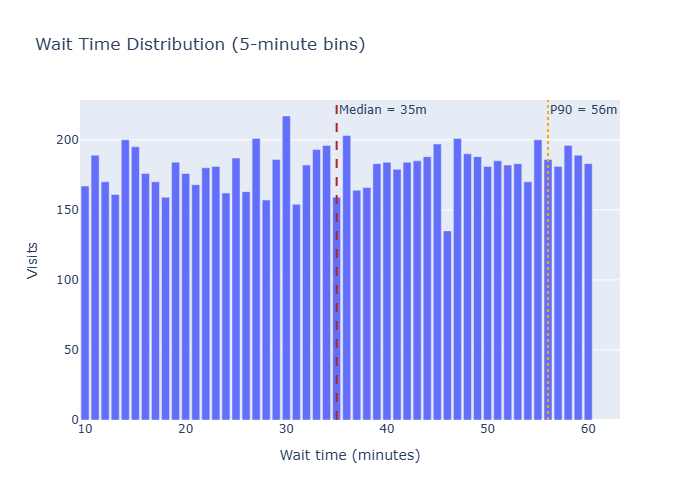

In [4]:
hist = metrics.wait_histogram(con, bin_width=5)
fig = px.bar(hist, x="bucket_start", y="n", title="Wait Time Distribution (5-minute bins)")
fig.add_vline(x=stats["median_wait"], line_dash="dash", line_color="firebrick",
              annotation_text=f"Median = {stats['median_wait']:.0f}m")
fig.add_vline(x=stats["p90_wait"], line_dash="dot", line_color="orange",
              annotation_text=f"P90 = {stats['p90_wait']:.0f}m")
fig.update_layout(xaxis_title="Wait time (minutes)", yaxis_title="Visits")
fig.show()


The histogram is broad and roughly flat-topped between about 15 and 55 minutes, with no long right tail
-- consistent with the near-zero skew and negative kurtosis above. This shape itself is somewhat atypical
for a real ED wait-time distribution, which usually has a sharper peak near a short wait and a long
right tail of outliers; see the Limitations section.

> **Business decision this supports:** because there is no long tail, a single target (P90 or median)
> captures the operational reality well -- there is no hidden population of extreme outlier waits that a
> median-only report would be hiding.


### Performance against the internal 30-minute target


Within target: 3,749 / 9,216 eligible visits (40.7%)


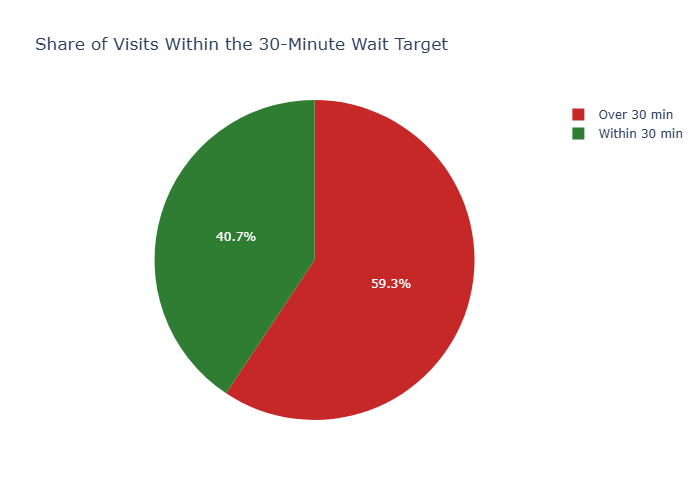

In [5]:
target = metrics.wait_within_target(con)
print(f"Within target: {target['within']:,.0f} / {target['eligible']:,.0f} eligible visits "
      f"({target['pct']:.1%})")

fig = px.pie(
    names=["Within 30 min", "Over 30 min"],
    values=[target["within"], target["eligible"] - target["within"]],
    title="Share of Visits Within the 30-Minute Wait Target",
    color=["Within 30 min", "Over 30 min"],
    color_discrete_map={"Within 30 min": "#2E7D32", "Over 30 min": "#C62828"},
)
fig.show()


Only 40.7% of visits are seen within the 30-minute internal target; 59.3% exceed it, and the P90 wait
(56 minutes) is nearly double the target. This is the central operational finding of this notebook: the
typical wait is not close to the target -- most patients wait longer than it.

> **Business decision this supports:** this is a target-attainment problem, not a tail-outlier problem
> (there's no small group of extreme waits dragging the average up). Closing the gap requires moving the
> whole distribution left (e.g. faster intake / triage throughput), not managing a handful of long-wait
> outliers.


## Executive Summary

The wait-time distribution is close to symmetric (skew ~-0.02) with no heavy tail (excess kurtosis
~-1.2, max observed wait 60 minutes), so the mean and median tell essentially the same story here. The
operationally significant finding is not the shape of the distribution but its *level*: only 40.7% of
visits are seen within the 30-minute internal target, and the P90 wait of 56 minutes is nearly double
that target.

## Business Recommendations

- Treat this as a target-attainment gap affecting the *typical* patient, not a tail-outlier problem --
  interventions should target overall intake/triage throughput rather than a small number of long-wait
  cases.
- Because the distribution has no long tail, P90 and median move together; either is a sufficient
  single number for a leadership scorecard, but report both since P90 communicates the "worst typical"
  experience more viscerally than a median.
- Revisit whether 30 minutes is the right internal target given current performance, or invest in the
  process changes needed to hit it -- 59.3% miss is a large gap to close either way.

## Limitations

- The near-symmetric, thin-tailed, hard-capped-at-60-minutes shape is atypical for real ED wait times
  and is consistent with this dataset's unverified/possibly-synthetic provenance (`docs/limitations.md`).
  A real facility's wait-time distribution should be re-examined for skew before dropping the median
  convention.
- The 30-minute target is a project analysis convention, not a regulatory or clinical threshold
  (`docs/measure_spec.md`).
- No acuity data means this distribution mixes all severities together; a sicker or more urgent subgroup
  may already be seen faster in practice, invisible in this aggregate.

## Next Steps

`03_load_vs_wait.ipynb` asks whether this wait level is driven by arrival volume, which would point to
a capacity fix rather than a process fix.
